In [12]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Noto Sans CJK JP"

In [3]:
from pathlib import Path
import pandas as pd

# プロジェクトのルートディレクトリ
ROOT_DIR = Path.cwd()

# データフォルダ
DATA_DIR = ROOT_DIR / "data"

# データ読み込み
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submit = pd.read_csv(
    DATA_DIR / "sample_submit.csv",
    header=None
)

# 確認
print(train.shape)
display(train.head())

(742, 43)


,企業ID,企業名,従業員数,業界,上場種別,特徴,企業概要,組織図,事業所数,工場数,...,アンケート４,アンケート５,アンケート６,アンケート７,アンケート８,アンケート９,アンケート１０,アンケート１１,今後のDX展望,購入フラグ
0,0,株式会社クロマファクトリー,4539,化学,PR,BtoB,【会社概要】\n\n当社は、化学業界に属し、先進の技術と豊富な実績を背景に、国内外のお客様に...,【経営層】\n├─ 代表取締役社長\n├─ 取締役副社長\n└─ 取締役\n\n【管理本部】...,2.0,10.0,...,1,5,2,NaN,3,4,1,1,弊社は、既存事業基盤を支える先端技術と品質管理体制をさらに磨くため、DX投資を持続可能かつ実...,0
1,1,星浪ホールディングス株式会社,792,運輸・物流,PR,BtoB,当社は運輸・物流業界に属し、792名の従業員と共に、バスや鉄道輸送、物流・海運、不動産・百貨...,経営層\n├─ 経営管理部\n│ ├─ 経営企画室\n│ └─ 財務・人事部\n├─...,2.0,NaN,...,3,4,1,5.0,4,1,2,1,当グループは運輸・物流、不動産・小売、ホテル・文化事業など幅広い事業を抱えるものの、これまで...,0
2,2,株式会社クネットリンク,4346,建設・工事,PR,BtoB,2010年に3社の経営統合により持株会社として設立され、業界3位を誇る電気通信工事会社です。...,経営層\n├─ 経営企画室\n├─ 管理本部\n│ ├─ 人事部\n│ ├─ 財務部\n│ ...,24.0,NaN,...,2,1,1,4.0,4,1,1,2,弊社はこれまで、社内DX導入において業界屈指の前のめり姿勢を貫き、AI・IoT・クラウドなど...,0
3,3,株式会社プリントスフィア,2011,機械,PR,BtoB,"【企業概要】\n当社は、従業員数2,011名を有し、機械業界に属するグローバル企業として、製...",【企業組織図】\n\n■ 経営層\n ├─ 経営企画部\n ├─ 自動認識ソリューション事業...,1.0,NaN,...,5,1,2,NaN,1,2,3,4,当社はこれまで、クラウド、AI、IoT などを活用した製造プロセス・サプライチェーンの効率化...,0
4,4,株式会社悠薫薬品,1488,医療・福祉,PR,BtoB,従業員数：1488人\n業界：医療・福祉業界\n\n事業内容：\n当社は、先発医薬品としての...,────────────────────────────\n【経営層】\n ├─ 代表取締役...,58.0,2.0,...,5,3,1,5.0,2,3,5,4,弊社はこれまで、クラウド、AI、IoT などを計画的に導入し、業務効率化や製品開発の高度化に...,0


In [6]:
train.isnull().sum().sort_values(ascending=False)

店舗数                   603
工場数                   403
アンケート７                356
経常利益                   83
営業利益                   43
事業所数                   16
資本金                     6
特徴                      2
従業員数                    0
企業ID                    0
企業名                     0
組織図                     0
業界                      0
上場種別                    0
企業概要                    0
負債                      0
短期借入金                   0
流動資産                    0
総資産                     0
純資産                     0
長期借入金                   0
売上                      0
自己資本                    0
当期純利益                   0
営業CF                    0
減価償却費                   0
固定資産                    0
運転資本変動                  0
投資CF                    0
無形固定資産変動(ソフトウェア関連)      0
有形固定資産変動                0
アンケート２                  0
アンケート３                  0
アンケート４                  0
アンケート１                  0
アンケート５                  0
アンケート６                  0
アンケート８                  0
アンケート９      

In [9]:
missing = pd.DataFrame({
    "欠損数": train.isnull().sum(),
    "欠損率(%)": (train.isnull().mean() * 100).round(2)
})

missing = missing[missing["欠損数"] > 0]
display(missing.sort_values("欠損数", ascending=False))

,欠損数,欠損率(%)
店舗数,603,81.27
工場数,403,54.31
アンケート７,356,47.98
経常利益,83,11.19
営業利益,43,5.80
事業所数,16,2.16
資本金,6,0.81
特徴,2,0.27


「購入フラグ」との相関

In [10]:
import pandas as pd

# 数値列のみ抽出
numeric_train = train.select_dtypes(include=["number"])

# 購入フラグとの相関
corr = numeric_train.corr(numeric_only=True)["購入フラグ"]

# 絶対値が大きい順に並べる
corr = corr.sort_values(key=abs, ascending=False)

display(corr.to_frame(name="相関係数"))

,相関係数
購入フラグ,1.000000
アンケート７,-0.258383
投資CF,-0.172996
営業利益,0.169139
有形固定資産変動,-0.166761
アンケート１０,-0.158307
純資産,0.156417
当期純利益,0.155807
無形固定資産変動(ソフトウェア関連),-0.155274
自己資本,0.155199


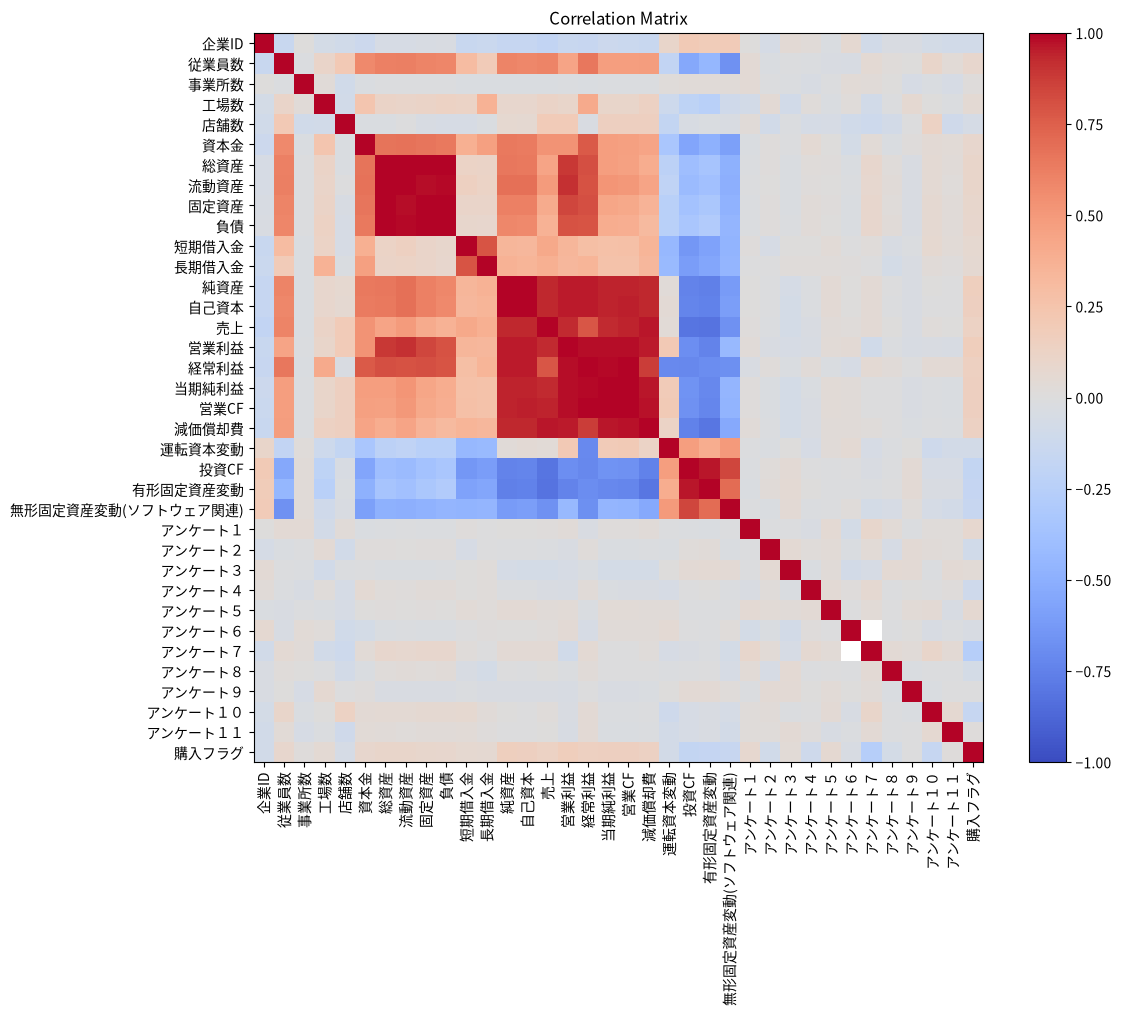

In [13]:
import matplotlib.pyplot as plt

corr = numeric_train.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

考察（特徴量同士の比較）

財務指標同士は非常に強い相関がある

<Figure size 600x500 with 0 Axes>

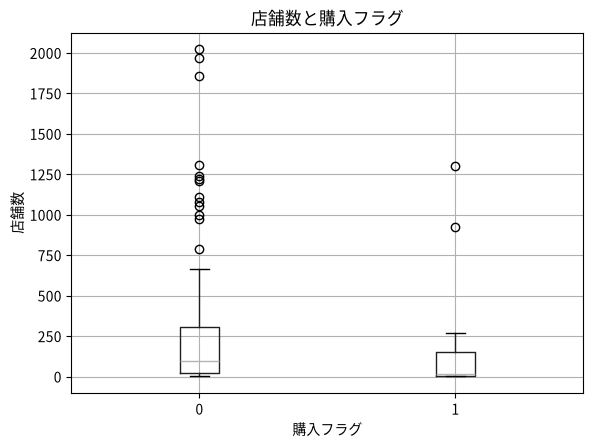

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

train.boxplot(column="店舗数", by="購入フラグ")

plt.title("店舗数と購入フラグ")
plt.suptitle("")   # 上の余計なタイトルを消す
plt.xlabel("購入フラグ")
plt.ylabel("店舗数")

plt.show()

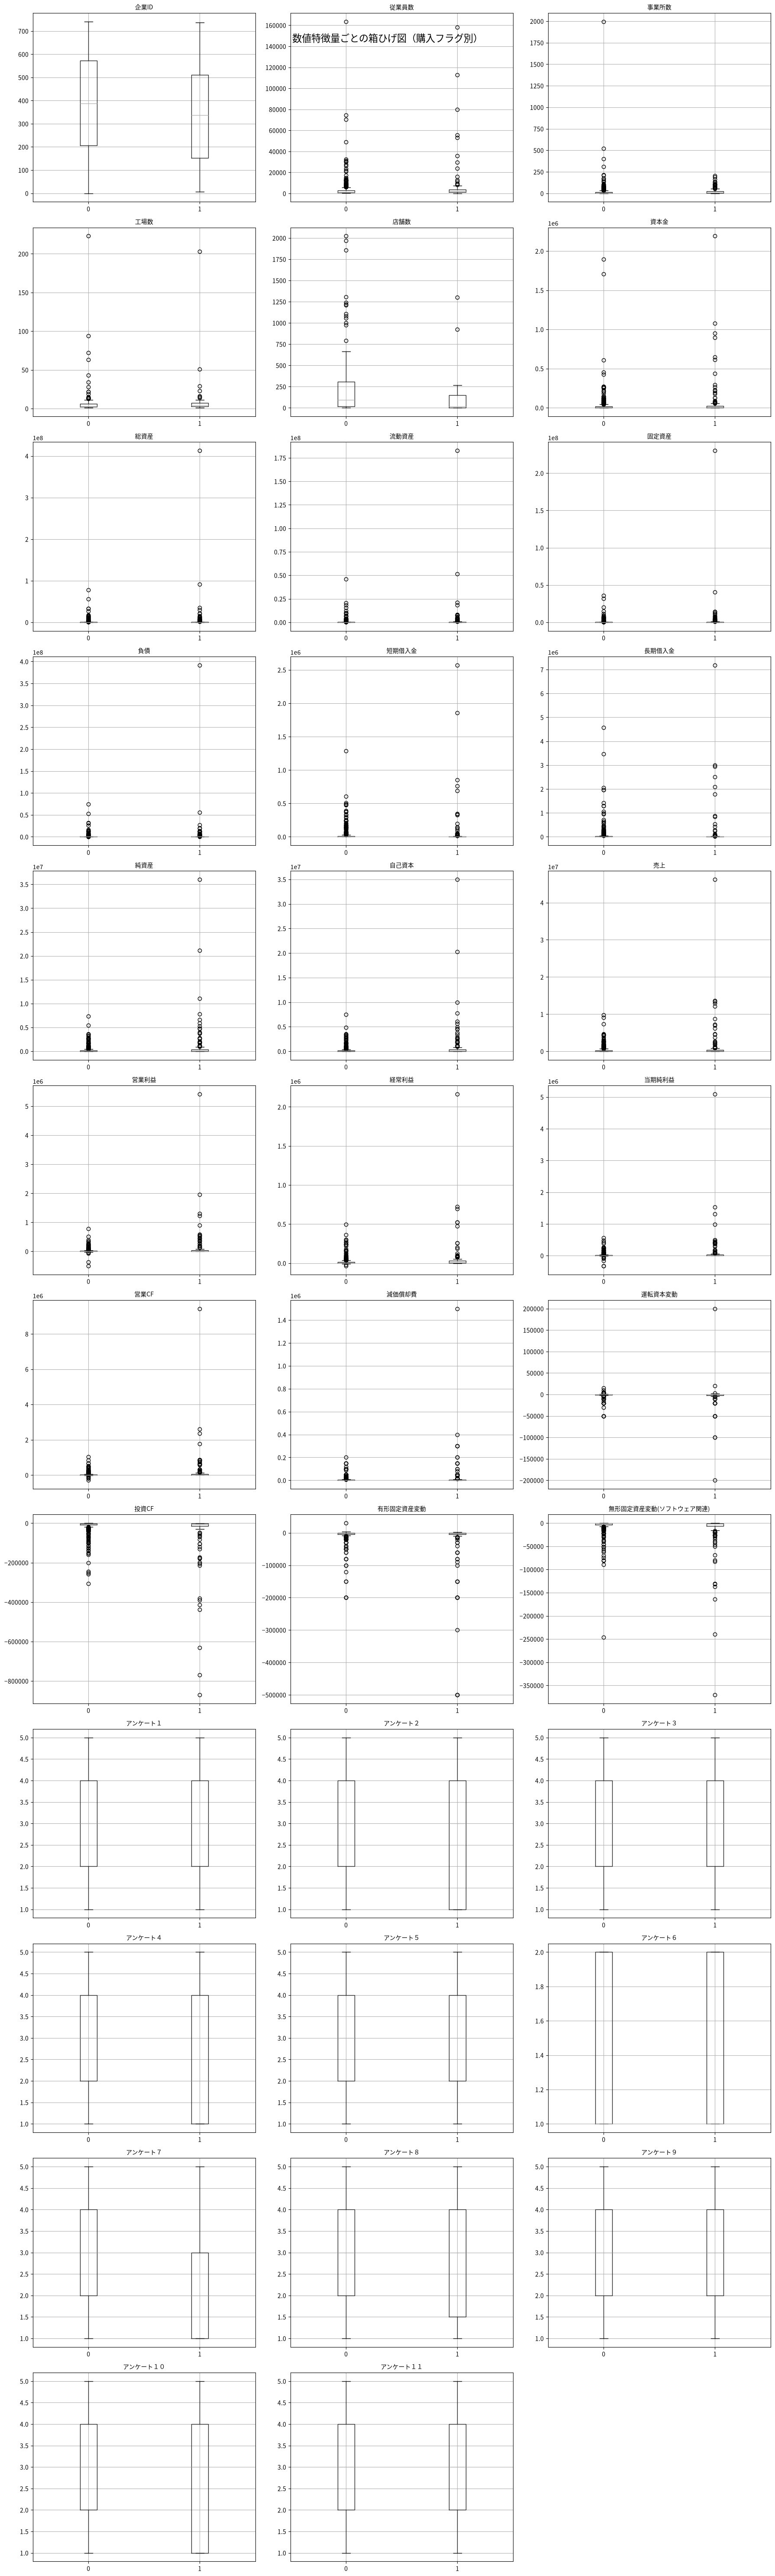

In [17]:
import matplotlib.pyplot as plt
import math

# 数値列を取得（目的変数は除く）
numeric_cols = train.select_dtypes(include="number").columns.drop("購入フラグ")

# レイアウト設定
n_cols = 3                      # 1行に3個表示
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# 箱ひげ図を描画
for i, col in enumerate(numeric_cols):
    train.boxplot(column=col, by="購入フラグ", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# 余ったグラフを削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("数値特徴量ごとの箱ひげ図（購入フラグ別）", fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
category_cols = train.select_dtypes(include="object").columns

for col in category_cols:
    print("=" * 50)
    print(col)
    display(train.groupby(col)["購入フラグ"].mean().sort_values(ascending=False))

企業名


/tmp/ipykernel_1224785/2174709948.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = train.select_dtypes(include="object").columns


企業名
響革新工業株式会社       1.0
風陽エネルギー株式会社     1.0
蒼月工業株式会社        1.0
遊幻創社株式会社        1.0
蒼海通信株式会社        1.0
               ... 
銀波ファイナンス株式会社    0.0
陽彩エネルギー株式会社     0.0
雲路株式会社          0.0
霧島生命医薬株式会社      0.0
霧野薬品株式会社        0.0
Name: 購入フラグ, Length: 742, dtype: float64

業界


業界
通信機器        1.000000
通信          0.800000
人材          0.500000
IT          0.467742
自動車・乗り物     0.448980
教育          0.333333
コンサルティング    0.333333
金融          0.333333
機械          0.283019
ゲーム         0.250000
エネルギー       0.250000
商社          0.228571
化学          0.225806
その他サービス     0.222222
アパレル・美容     0.157895
製造          0.153846
エンタメ        0.142857
電気製品        0.142857
医療・福祉       0.125000
生活用品        0.117647
建設・工事       0.090909
運輸・物流       0.080000
食品          0.080000
不動産         0.076923
小売          0.073171
外食          0.050000
その他         0.000000
マスコミ        0.000000
機械関連サービス    0.000000
専門サービス      0.000000
広告          0.000000
Name: 購入フラグ, dtype: float64

...

企業概要
当社は、IT業界に属し、従業員数532名を擁する企業です。企業向けに、膨大なデータの蓄積から先進的な分析、そして分析結果に基づく最適な施策の実行支援を可能とするソフトウェアの選定および提供を事業の中核としております。\n\n具体的には、複数のデータソースからの情報統合・分析を実現するためのプラットフォームや、自然言語処理エンジンを主要製品としてラインナップしています。また、データの見える化を促進する可視化ツールや、さらには拡張分析ツールなど、多角的なソリューションを提供しております。\n\nこれらの製品は、主要なクラウド基盤や汎用的な基盤技術を活用することで、お客様の多様なニーズに柔軟かつ迅速に対応し、企業のデジタルトランスフォーメーションを力強くサポートいたします。                                                                                                                                                                                                                                                                                 1.0
当社は、IT業界に属し、従業員783名を擁する技術革新に取り組む企業です。自動車整備事業者、旅行取扱い事業者、携帯電話販売代理店、機械工具取扱い事業者等をはじめとする各業種のお客様向けに、業種特化型業務アプリケーションの開発および販売を行っています。中核となるサービスとして、自動車整備に特化した専用システムを提供。整備や車検の履歴情報管理、見積書・伝票の発行、さらに効率的な顧客アプローチのための提案など、業務効率改善と経営課題の解決を実現しています。\n\nまた、パソコン本体やプリンタなどの仕入・販売、システム販売後の保守・データベース提供、さらには自動車リサイクル部品の決済代行といった幅広い付随サービスも展開。加えて、自動車補修部品専門のショッピングサイトや、福利厚生に関するアウトソーシングサービスをWeb上で運営・管理することで、顧客ニーズに柔軟

組織図


組織図
＜第一階層＞  \n  【営業層】\n\n   │\n   ├─────────────────────┬─────────────────────┬─────────────────────  \n   │                     │                     │  \n   │                     │                     │  \n  ＜第二階層＞    【個人営業部】    【法人営業部】    【営業支援部】\n\n   │                     │                     │  \n   │                     │                     ├─────────────  \n   │                     │                     │  \n   │                     │                     │ ＜第三階層＞（各部内の機能）  \n   │                     │                     │  \n   │                     │                     ├─【DX推進室】※必ず配置  \n   │                     │                     ├─【総務・人事・経理】  \n   │                     │                     └─【リスク管理・IT部】  \n\n  【個人営業部】の下（第三階層例）  \n   ├─【店舗営業部】     　　← 店舗・支店ネットワークを統括  \n   └─【ATMネットワーク部】   ← 当社のATM網の拡充や運用を担当\n\n  【法人営業部】の下（第三階層例）  \n   ├─【中小企業向け営業部】  ← 地域に根ざした法人向けサービス  \n   └─【大企業・投資銀行部門】 ← 複雑な取引や資本市場関連の業務    1.0
経営層  \n├─ 代表取締役社長  \n│  \n├─ 経営企画室  \n│  \n├─ 管理部  \n│ ├─ 

今後のDX展望


今後のDX展望
当社グループは、これまで社内DXを「優先度の高い成長施策の一つ」と位置づけ、戦略の明確化や推進組織の整備、海外子会社との連携強化など一定の成果を上げてまいりました。クラウド基盤の早期導入や建造物向け特殊施工部門でのデジタル連携は社外からも好評価を得ており、既存事業とのシナジー創出に手応えを感じています。しかしながら、これまでは各部門での実証や限定的導入が中心で、全社規模で一気に踏み込む段階にはまだ至っていないという課題も認識しております。  \n\n今後は、現状で築いた基盤を飛躍的にスケールさせる「全社・全拠点・全員」を対象とした大規模DXへ展開します。AI、IoT、クラウドネイティブ技術の採用範囲を一気に拡大し、データが自律的に流通する企業プラットフォームを構築、スマートファクトリーとスマートオフィスを同時に実現します。全社横断のデータ分析基盤を再設計し、ビッグデータ利活用による業務プロセス刷新、品質向上、製品開発リードタイム短縮を徹底的に推し進め、既存の生産・管理体制を根底から変革してまいります。  \n\nこれら技術投資を最大限に活かすため、従業員一人ひとりのDXリテラシー向上を最重要施策とし、従来の初歩的研修から一段階上の「全員が実務で先端技術を使いこなす」水準を目標に据えます。オンライン学習プラットフォームの刷新、外部セミナーや国際的技術イベントへの参加奨励、専門ベンダー・コンサルタントとの協働など、学習機会へ抜本的に投資します。さらに、海外子会社と本社が同一基準で知識を共有できる仕組みを整備し、グローバル全体で知見を循環させる体制を確立します。  \n\n加えて、サイバーセキュリティはDX推進の大前提と位置づけ、ゼロトラストモデルを軸とした情報統制を再構築します。長期的なリスクマネジメント計画に基づき、専任組織と最新ソリューションへの投資を強化し、安全性と機動力を両立させます。  \n\nこうした総合的な取り組みにより、当社は財務的裏付けを最大限活用しながら、これまで以上にアグレッシブで迅速なDXを全社的に推進します。技術革新と人材育成を両輪とし、市場変化に柔軟かつ即応できる企業体質を築き、グローバル競争での優位性を圧倒的なものへと高めてまいります。全社員が同じゴールを共有し、未来志向でチャレンジし続ける企業文化を醸成することで、持続可能

考察

業界と業態の特徴によって購入率が違う。よって業界と業態の特徴は購入フラグを予測するうえで有効な特徴量となる可能性がある。

In [ ]:
import matplotlib.pyplot as plt
import math

# 数値列を取得（目的変数は除く）
numeric_cols = train.select_dtypes(include="number").columns.drop("購入フラグ")

# レイアウト設定
n_cols = 3                      # 1行に3個表示
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# 箱ひげ図を描画
for i, col in enumerate(numeric_cols):
    train.boxplot(column=col, by="購入フラグ", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# 余ったグラフを削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("数値特徴量ごとの箱ひげ図（購入フラグ別）", fontsize=16)
plt.tight_layout()
plt.show()